# 🧠 Agent 실습 2 – LangGraph 기초


### 학습 목표
1. LangGraph의 핵심 개념 **State / Node / Edge** 를 이해합니다.
2. 수동 구현과 동일한 문제를 LangGraph로 구현하고 차이를 비교합니다.
3. **그래프 시각화**와 **실행 중 상태 추적**을 실습합니다.
4. 마지막에는 **Tool을 쉽게 추가**하여 최종적으로 **5개의 Tool**을 장착한 만능 Agent를 완성합니다.

---
## ⚙️ 1. 환경 설정 & Tool 재정의

In [1]:
!pip install openai langgraph langchain langchain-openai wikipedia requests pandas python-dotenv -q

In [2]:
import os
import json
import requests
import wikipedia
import pandas as pd
from datetime import datetime
from typing import Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

load_dotenv()
MODEL = "gpt-4o-mini"
print("✅ 환경 설정 완료")

c:\Users\minso\anaconda3\envs\session4\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


✅ 환경 설정 완료


In [3]:
# LangGraph에서 사용할 Tool: @tool 데코레이터로 정의
# → LangChain이 함수 시그니처 + Docstring을 읽어 자동으로 스키마를 생성합니다

@tool
def get_exchange_rate(currency: str) -> str:
    """
    지정된 통화(USD, EUR, JPY 등)의 현재 원화(KRW) 환율을 조회합니다.
    사용자가 특정 외화를 원화로 환산하거나 현재 환율을 묻는 경우에 사용하세요.
    """
    url = f"https://api.frankfurter.app/latest?from={currency.upper()}&to=KRW"
    try:
        data = requests.get(url, timeout=5).json()
        rate = data["rates"]["KRW"]
        return f"현재 1 {currency.upper()}의 환율은 {rate:.2f} KRW입니다."
    except Exception as e:
        return f"{currency} 환율 정보를 가져오는 데 실패했습니다: {e}"


@tool
def search_wikipedia(query: str) -> str:
    """
    위키백과에서 특정 주제에 대한 일반적인 사실 정보를 검색합니다.
    인물, 장소, 역사적 사건, 개념 등의 일반 지식을 조회할 때 사용하세요.
    """
    try:
        wikipedia.set_lang("ko")
        return wikipedia.summary(query, sentences=2)
    except wikipedia.exceptions.PageError:
        return f"'{query}'에 대한 위키백과 페이지를 찾을 수 없습니다."
    except Exception as e:
        return f"위키백과 검색 중 오류 발생: {e}"


@tool
def get_current_weather(city: str) -> str:
    """
    특정 도시의 현재 날씨를 알려줍니다.
    사용자가 특정 도시의 날씨, 기온 등을 묻는 경우에 사용하세요.
    """
    city_lower = city.lower()
    weather_data = {
        "도쿄": "맑음, 28°C", "tokyo": "맑음, 28°C",
        "서울": "흐림, 24°C", "seoul": "흐림, 24°C",
        "뉴욕": "비, 18°C",   "new york": "비, 18°C",
    }
    for key, val in weather_data.items():
        if key in city_lower:
            return val
    return f"'{city}'의 날씨 정보를 찾을 수 없습니다."


@tool
def summarize_csv(file_path: str) -> str:
    """
    CSV 파일의 경로를 입력받아 데이터의 기본적인 통계 정보를 반환합니다.
    사용자가 CSV 파일의 내용 요약, 통계, 또는 분석을 요청할 때 사용하세요.
    """
    try:
        df = pd.read_csv(file_path)
        summary  = f"파일: {file_path} | 행: {len(df)}, 열: {len(df.columns)}\n"
        summary += f"컬럼: {list(df.columns)}\n"
        summary += df.describe().to_string()
        return summary
    except FileNotFoundError:
        return f"'{file_path}' 파일을 찾을 수 없습니다."
    except Exception as e:
        return f"파일 처리 중 오류 발생: {e}"


tools = [get_exchange_rate, search_wikipedia, get_current_weather, summarize_csv]

print("✅ @tool 데코레이터로 Tool 4개 정의 완료")
print(f"   → {[t.name for t in tools]}")

✅ @tool 데코레이터로 Tool 4개 정의 완료
   → ['get_exchange_rate', 'search_wikipedia', 'get_current_weather', 'summarize_csv']


---
## 📖 2. LangGraph 핵심 개념

```
무엇을 기억할 것인가        →  State
무슨 작업을 할 것인가       →  Node
어떤 순서로 이동할 것인가   →  Edge
조건에 따라 어디로 갈 것인가 →  Conditional Edge
```


## 🏗️ 3. 처음 Agent 만들기 + 그래프 시각화

LangGraph로 Agent를 만드는 과정은 딱 6단계입니다.

In [7]:
# ── Step 1. State 정의 ──────────────────────────────────────
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]


# ── Step 2. LLM 바인딩 ──────────────────────────────────────
llm = ChatOpenAI(model=MODEL, temperature=0)
llm_with_tools = llm.bind_tools(tools)   # Tool 목록을 LLM에 등록


# ── Step 3. Node 정의 ──────────────────────────────────────
def call_llm(state: AgentState) -> dict:
    """LLM을 호출하여 응답을 생성하는 Node"""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# ToolNode: Tool 실행을 담당하는 LangGraph 내장 Node
# 직접 구현 없이 Tool 목록만 넘기면 됩니다
tool_node = ToolNode(tools)


# ── Step 4. Conditional Edge 함수 ─────────────────────────
def should_continue(state: AgentState) -> str:
    """마지막 메시지에 tool_calls가 있으면 Tool 실행, 없으면 종료"""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "use_tool"
    return "finish"


# ── Step 5. 그래프 조립 ────────────────────────────────────
builder = StateGraph(AgentState)

builder.add_node("call_llm",      call_llm)    # Node 추가
builder.add_node("execute_tools", tool_node)   # Node 추가

builder.add_edge(START, "call_llm")            # 시작 → LLM
builder.add_conditional_edges(                 # LLM → (조건 분기)
    "call_llm",
    should_continue,
    {"use_tool": "execute_tools", "finish": END}
)
builder.add_edge("execute_tools", "call_llm") # Tool 실행 후 → LLM (루프)


# ── Step 6. 컴파일 ────────────────────────────────────────
agent_app = builder.compile()

print("✅ LangGraph Agent 구성 완료")

✅ LangGraph Agent 구성 완료


In [5]:
# 그래프 노드 & 엣지 구조 확인
print("=== 노드 목록 ===")
print(list(agent_app.get_graph().nodes.keys()))

print("\n=== 엣지 목록 ===")
for edge in agent_app.get_graph().edges:
    print(f"  {edge[0]:20s} → {edge[1]}")

=== 노드 목록 ===
['__start__', 'call_llm', 'execute_tools', '__end__']

=== 엣지 목록 ===
  __start__            → call_llm
  call_llm             → __end__
  call_llm             → execute_tools
  execute_tools        → call_llm


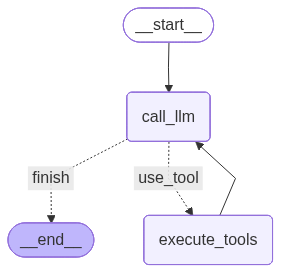

In [6]:
# 그래프 시각화 (Mermaid 다이어그램)
# 내부에서 어떤 흐름으로 실행되는지 한눈에 확인할 수 있습니다
try:
    from IPython.display import Image, display
    display(Image(agent_app.get_graph().draw_mermaid_png()))
except Exception:
    # draw_mermaid_png가 안 되는 환경에서는 텍스트(Mermaid 문법)로 출력
    print(agent_app.get_graph().draw_mermaid())

---
## 🔍 4. 실행 중 State 변화 추적

LangGraph의 가장 큰 장점 중 하나는 **실행 중 상태를 들여다볼 수 있다**는 점입니다.

`app.stream()`을 사용하면 각 Node가 실행될 때마다 State 변화를 **실시간으로** 확인할 수 있습니다.  
이것이 `AgentExecutor` 같은 블랙박스 방식과 LangGraph를 구별 짓는 핵심 기능입니다.

In [8]:
print("=== 실행 중 State 변화 추적 ===")
print("질문: 현재 USD 환율 알려줘\n")

inputs = {"messages": [HumanMessage(content="현재 USD 환율 알려줘")]}

for step, state_update in enumerate(agent_app.stream(inputs), 1):
    node_name   = list(state_update.keys())[0]
    node_output = state_update[node_name]
    last_msg    = node_output["messages"][-1]

    print(f"── Step {step}: [{node_name}] ──")
    print(f"   메시지 타입: {type(last_msg).__name__}")

    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        for tc in last_msg.tool_calls:
            print(f"   Tool 호출: {tc['name']}({tc['args']})")
    elif hasattr(last_msg, "content"):
        preview = str(last_msg.content)[:120]
        print(f"   내용: {preview}{'...' if len(str(last_msg.content)) > 120 else ''}")
    print()

=== 실행 중 State 변화 추적 ===
질문: 현재 USD 환율 알려줘

── Step 1: [call_llm] ──
   메시지 타입: AIMessage
   Tool 호출: get_exchange_rate({'currency': 'USD'})

── Step 2: [execute_tools] ──
   메시지 타입: ToolMessage
   내용: 현재 1 USD의 환율은 1516.65 KRW입니다.

── Step 3: [call_llm] ──
   메시지 타입: AIMessage
   내용: 현재 1 USD의 환율은 1,516.65 KRW입니다.



---
## ✨ 5. 수동 구현 vs LangGraph 비교

이전 파일에서 4번의 LLM 호출이 필요했던 Multi-Step 문제를 LangGraph로 실행해봅니다.

In [9]:
print("===== LangGraph Agent 실행 =====")
question = "일본의 수도는 어디인지 위키백과에서 찾고, 그 도시의 현재 날씨를 알려줘."
print(f"질문: {question}\n")

result = agent_app.invoke({"messages": [HumanMessage(content=question)]})

print("===== Agent의 최종 답변 =====")
print(result["messages"][-1].content)

===== LangGraph Agent 실행 =====
질문: 일본의 수도는 어디인지 위키백과에서 찾고, 그 도시의 현재 날씨를 알려줘.

===== Agent의 최종 답변 =====
일본의 수도는 도쿄입니다. 현재 도쿄의 날씨는 맑고 기온은 28°C입니다.


### 비교 정리

| 항목 | 수동 구현 | LangGraph |
|:--- |:--- |:--- |
| **코드 길이** | 매우 김 (LLM 호출 4번 + 변수 관리) | 짧음 (`invoke` 1번) |
| **상태 관리** | 직접 변수에 저장 → 에러에 취약 | State로 자동 관리 |
| **루프** | 단계 수를 코드에 미리 고정 | 조건에 따라 자동 반복 |
| **과정 추적** | `print`문을 직접 추가 | `stream()`으로 실시간 확인 |
| **구조 파악** | 코드를 전부 읽어야 함 | 그래프 시각화로 한눈에 파악 |

---
## 🤖 6. 실전 Tool 제작 & 만능 Agent

지금까지는 Tool 4개로 Agent를 만들었습니다.
이제 여기서 **D-Day 계산 Tool을 새로 정의해서 추가**해보고, Tool이 늘어나도 **그래프 코드를 크게 바꾸지 않고** 확장할 수 있다는 걸 확인해봅시다.

In [10]:
# ✅ (새 Tool 추가) D-Day 계산 Tool 정의 → tools에 추가 → Agent 재컴파일

@tool
def d_day_calculator(target_date: str) -> str:
    """
    목표 날짜('YYYY-MM-DD' 형식)를 기준으로 오늘부터 며칠 남았는지 또는 지났는지 계산합니다.
    사용자가 특정 날짜까지의 D-Day나 남은 날수를 묻는 경우에 사용하세요.
    날짜는 반드시 'YYYY-MM-DD' 형식(예: 2025-11-13)으로 변환하여 전달하세요.
    """
    try:
        today  = datetime.now().date()
        target = datetime.strptime(target_date, "%Y-%m-%d").date()
        delta  = (target - today).days
        if delta == 0:
            return f"{target_date}은(는) 오늘입니다!"
        if delta > 0:
            return f"{target_date}까지 {delta}일 남았습니다."
        return f"{target_date}부터 {-delta}일이 지났습니다."
    except ValueError:
        return "날짜 형식이 잘못되었습니다. 'YYYY-MM-DD' 형식으로 입력해주세요."


# Tool 목록에 추가
tools = tools + [d_day_calculator]
print(f"✅ Tool 추가 완료 → {[t.name for t in tools]}")


# Tool이 늘어나도 바뀌는 건 'tools'만입니다.
# (재컴파일은 한 번만 해주면 됩니다)
llm_with_tools = llm.bind_tools(tools)

def call_llm(state: AgentState) -> dict:
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

tool_node = ToolNode(tools)

builder = StateGraph(AgentState)
builder.add_node("call_llm", call_llm)
builder.add_node("execute_tools", tool_node)
builder.add_edge(START, "call_llm")
builder.add_conditional_edges(
    "call_llm",
    should_continue,
    {"use_tool": "execute_tools", "finish": END},
)
builder.add_edge("execute_tools", "call_llm")

agent_app = builder.compile()
print("✅ (업데이트) LangGraph Agent 재컴파일 완료")


✅ Tool 추가 완료 → ['get_exchange_rate', 'search_wikipedia', 'get_current_weather', 'summarize_csv', 'd_day_calculator']
✅ (업데이트) LangGraph Agent 재컴파일 완료


In [11]:
# 실습용 CSV 파일 생성
csv_data = """Date,Product,Sales
2024-01-01,Laptop,1200
2024-01-02,Mouse,25
2024-01-03,Keyboard,75
2024-01-04,Laptop,1250
2024-01-05,Monitor,300
2024-01-06,Mouse,30
2024-01-07,Keyboard,80"""

with open("sales_data.csv", "w") as f:
    f.write(csv_data)
print("'sales_data.csv' 파일이 생성되었습니다.")

'sales_data.csv' 파일이 생성되었습니다.


In [12]:
# Tool이 늘어나도 그래프 구조는 완전히 동일합니다
# LangGraph의 장점: Tool 수가 늘어나도 그래프 코드를 바꿀 필요가 없습니다

def run_agent(question: str):
    print(f"\n{'='*55}")
    print(f"❓ 질문: {question}")
    print('='*55)
    result = agent_app.invoke({"messages": [HumanMessage(content=question)]})
    print(f"✅ 답변: {result['messages'][-1].content}")


# 테스트 1: 환율 조회
run_agent("일본 엔화(JPY) 환율 알려줘.")


❓ 질문: 일본 엔화(JPY) 환율 알려줘.
✅ 답변: 현재 1 일본 엔화(JPY)의 환율은 9.50 원(KRW)입니다.


In [13]:
# 테스트 2: CSV 분석
run_agent("sales_data.csv 파일의 판매 통계를 요약해줘.")


❓ 질문: sales_data.csv 파일의 판매 통계를 요약해줘.
✅ 답변: `sales_data.csv` 파일의 판매 통계는 다음과 같습니다:

- **총 행 수**: 7
- **총 열 수**: 3
- **판매 수치 요약**:
  - **판매 수**:
    - **개수**: 7
    - **평균**: 422.86
    - **표준편차**: 555.94
    - **최소값**: 25
    - **25% 분위수**: 52.50
    - **중앙값 (50%)**: 80.00
    - **75% 분위수**: 750.00
    - **최대값**: 1250.00

이 통계는 판매 데이터의 분포와 변동성을 보여줍니다.


In [14]:
# 테스트 3: D-Day 계산
run_agent("2026년 수능일인 2025년 11월 13일까지 며칠 남았어?")


❓ 질문: 2026년 수능일인 2025년 11월 13일까지 며칠 남았어?
✅ 답변: 2025년 11월 13일까지는 143일이 지났습니다.


In [15]:
# 테스트 4: 위키백과 + 날씨 (Multi-Tool)
# 수동으로는 LLM을 4번 호출해야 했던 문제를 LangGraph는 자동으로 처리합니다
run_agent("일본의 수도는 어디인지 위키백과에서 찾고, 그 도시의 현재 날씨도 알려줘.")


❓ 질문: 일본의 수도는 어디인지 위키백과에서 찾고, 그 도시의 현재 날씨도 알려줘.
✅ 답변: 일본의 수도는 도쿄입니다. 현재 도쿄의 날씨는 맑고 기온은 28°C입니다.


> **결론**: 우리 Agent는 환율 조회, CSV 분석, D-Day 계산, 위키백과 검색, 날씨 확인이라는  
> 다섯 가지 능력을 모두 갖추게 되었습니다.  
> Agent는 질문의 의도를 스스로 파악하고, 가장 적합한 Tool을 정확히 선택합니다.

---

다음 파일(`3_langgraph_advanced.ipynb`)에서는 실제 서비스를 만들 때 필요한  
**컨텍스트 관리, 메모리, 구조화된 응답, Human-in-the-Loop** 을 실습합니다.